# Grade Transition Analysis

## Grade Matrix


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
grade_data = pd.read_csv("../Data/student_results.csv")
grade_data.head()

grade_map = {"S" : 0, "E": 1, "D" : 2, "C": 3, "B": 4, "A" : 5}
grade_data["Initial_Grade"] = grade_data["Initial_Grade"].map(grade_map)
grade_data["Final_Grade"] = grade_data["Final_Grade"].map(grade_map)

#grade_data["Initial_Grade"] = grade_data["Initial_Grade"].astype(int)
grade_data["Improvement"] = grade_data["Final_Grade"] - grade_data["Initial_Grade"]

grade_data.head()




,Student_ID,Initial_Grade,Final_Grade,Improvement
0,1,3,5,2
1,2,1,4,3
2,3,1,5,4
3,4,3,5,2
4,5,1,4,3


## Improvement Analysis

In [4]:
grade_data["Improvement"].describe()

count    12.000000
mean      3.000000
std       0.953463
min       2.000000
25%       2.000000
50%       3.000000
75%       3.250000
max       5.000000
Name: Improvement, dtype: float64

### Insights into Overall Improvement Statistics

With the mean and minimum improvement score being above 2, this indicates that students improved by about 2 grades after the tutoring provided. This is supported using the plots below.

## Visualizing and Interpreting Improvement

   B  A
S  1  1
D  3  1
E  2  2
C  0  2


Text(45.722222222222214, 0.5, 'Initial Grade')

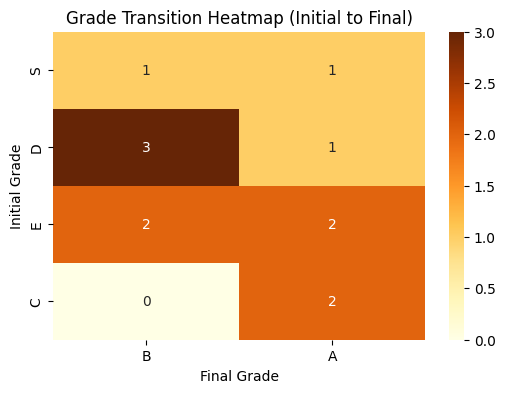

In [11]:
grade_transition = pd.crosstab(grade_data["Initial_Grade"], grade_data["Final_Grade"])
grade_transition.index = ["S", "D", "E", "C"]
grade_transition.columns = ["B", "A"]
print(grade_transition)

plt.figure(figsize = (6,4))
sns.heatmap(grade_transition, annot = True, fmt = "d", cmap = "YlOrBr")
plt.title("Grade Transition Heatmap (Initial to Final)")
plt.xlabel("Final Grade")
plt.ylabel("Initial Grade")




<Axes: title={'center': 'Improvement by Initial Grade'}, xlabel='Initial Grade', ylabel='Improvement Score'>

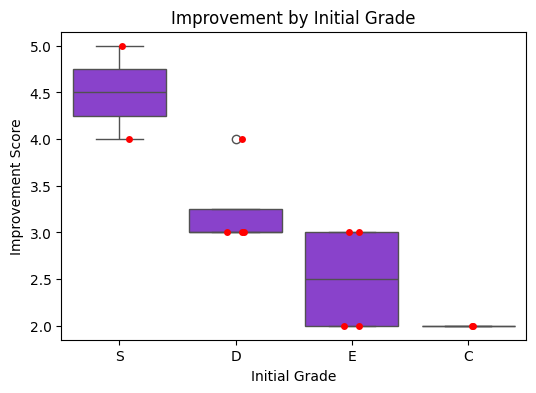

In [12]:
plt.figure(figsize = (6,4))

sns.boxplot(x = "Initial_Grade", y = "Improvement", data = grade_data, color = "blueviolet")
plt.title("Improvement by Initial Grade")
plt.xticks(ticks = [0,1,2,3], labels = ["S", "D", "E", "C"])
plt.xlabel("Initial Grade")
plt.ylabel("Improvement Score")

sns.stripplot(x  = "Initial_Grade", y = "Improvement", data = grade_data, color = "red", size = 5,
jitter = True)

From the heatmap, most students that started with a E grade progressed to a B grade, with an exception of a A grade. This is indicative of a consistent 3 grade improvement. Interestingly, students that started with a D grade jumped to at least a B grade, with some achieving an A. All students who started with a C grade improved to an A. 

All students managed to improve by at least 2 grades, where there are no cases of students who remained at the same grade. The boxplot reiterates this improvement score of at least 2. Overall, this suggests positive effects and outcomes of the tuition provided to the students.







Text(0.5, 1.0, 'Raw Improvement Scores For Each Starting Grade')

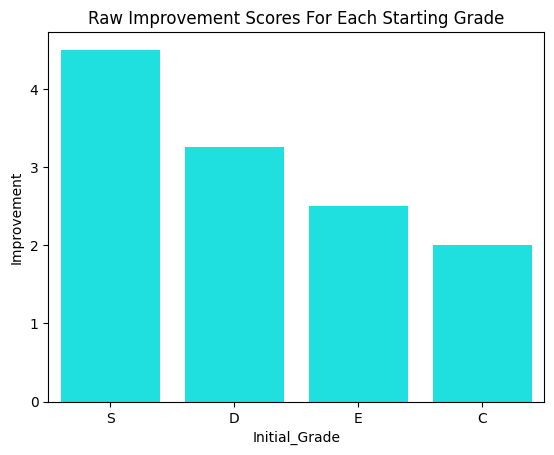

In [13]:

improvement_table = grade_data.pivot_table(index = "Initial_Grade", values = "Improvement")
improvement_table.head()
sns.barplot(x = "Initial_Grade", y = "Improvement", data = improvement_table, color = "cyan")
plt.xticks(ticks = [0,1,2,3], labels = ["S", "D", "E", "C"])
plt.title("Raw Improvement Scores For Each Starting Grade")


Here we see that students who were weaker at the start attained higher raw improvement scores. There is potentially some bias here since students who started with a lower score would naturally have more room for improvement, while students who were already relatively stronger from the start had an "improvement cap", thus it may seem as if they did not improve as much as the weaker students did.

Instead, it may be more effective to compare via a "gap closure" metric, where we investigate the percentage of possible gain for each group of starting grade, A grade being the best possible improvement.

([<matplotlib.axis.XTick at 0x291c6dcd610>,
 [Text(0, 0, 'S'), Text(1, 0, 'E'), Text(2, 0, 'D'), Text(3, 0, 'C')])

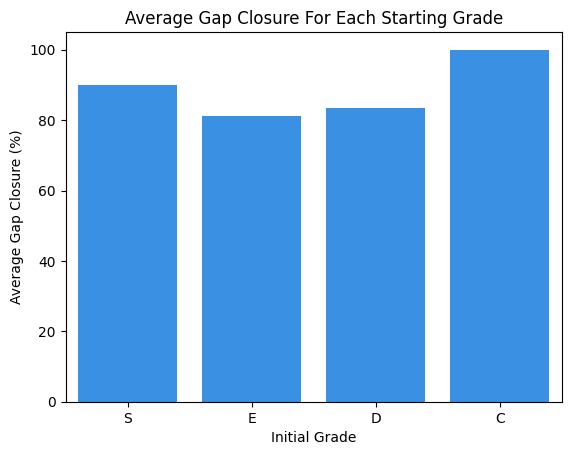

In [8]:
grade_data["Gap Closure"] = (grade_data["Improvement"] / (5 - grade_data["Initial_Grade"])) * 100
eff_table = grade_data.groupby("Initial_Grade").agg(average_final_grade = ("Final_Grade", "mean"), 
average_gap_closure_percent = ("Gap Closure", "mean"))
eff_table.head()

sns.barplot(x = "Initial_Grade", y = "average_gap_closure_percent", data = eff_table, color = "dodgerblue")
plt.xlabel("Initial Grade")
plt.ylabel("Average Gap Closure (%)")
plt.title("Average Gap Closure For Each Starting Grade")
plt.xticks([0,1,2,3], ["S", "E", "D", "C"])


We observe that every starting-grade category achieved an average gap closure of approximately 80%, suggesting that the earlier “improvement cap” did not prevent stronger students, particularly those who started at grade C, from continuing to perform well and remain consistent. In fact, the 100% gap closure among these students shows that performance should not be evaluated solely by the size of the raw grade improvement; final attainment and the extent to which students close the remaining gap to the top grade are also important considerations.

Conversely, students who started from weaker positions, such as S and E grades, recorded a slightly lower average gap closure rate. However, this does not necessarily mean they performed worse than the stronger students simply because they did not reach an A grade. Rather, these students still demonstrated the largest raw improvement scores, suggesting that they made substantial academic progress from their respective starting points.

Overall, the findings show that no single measure fully captures student performance. A more balanced interpretation comes from considering both raw improvement and gap closure together, as they highlight different but equally meaningful forms of academic progress.

## Final Grade Distribution

<Axes: xlabel='Final_Grade', ylabel='count'>

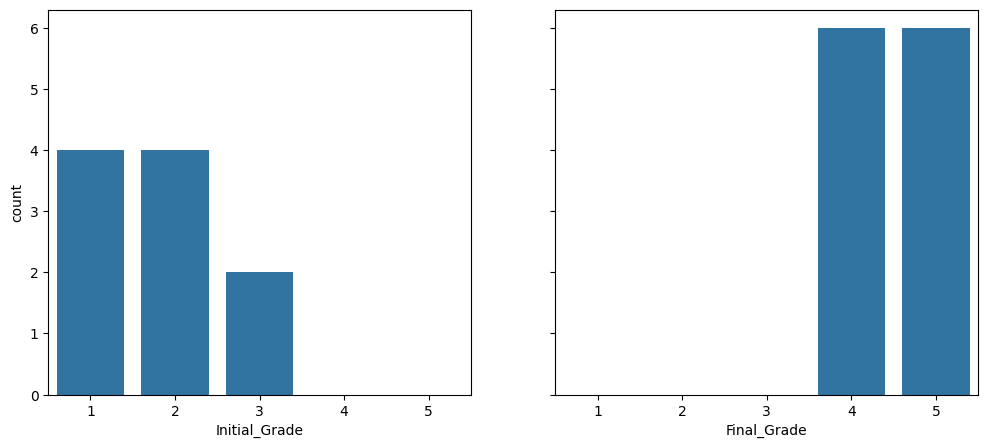

In [14]:
grade_order = [1, 2, 3, 4, 5]
fig, axes = plt.subplots(1,2, figsize = (12, 5), sharey = True)

sns.countplot(data = grade_data, x = "Initial_Grade", order = grade_order, ax = axes[0])
sns.countplot(data = grade_data, x = "Final_Grade", order = grade_order, ax = axes[1])



## Conclusion

The comparison between initial and final grade distributions shows a clear upward shift in student outcomes. While students initially started in lower and middle grade bands, all final grades were concentrated in B and A, suggesting that the improvements observed were associated with strong final academic performance. Combined with the earlier improvement and gap-closure findings, this provides a more complete view of tutoring effectiveness across the cohort of students taken in. 

## Limitations

This analysis should be interpreted with several limitations in mind. First, the dataset is small, consisting of only a limited number of students. Therefore, the findings are more illustrative of this tutoring sample, instead of being broadly generalizable. Secondly, the dataset does not include other potentially important explanatory variables, such as the total number of lessons for an individual lesson, and prior academic background. As a result, the analysis is best understood as a focused explanatory study of observed grade outcomes, rather than a complete explanation of all factors that ultimately influence a student's performance. 